In [2]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score, auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [4]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

TEST_LOCS_KEY = 'test_locs'
TEST_IDS_KEY = 'test_pos_inds'

Reading the file:

In [6]:
filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Reading test file

In [7]:
test_filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_test.npz')
test_data = np.load(test_filepath, allow_pickle=True)
test_locs = test_data[TEST_LOCS_KEY]
test_ids = test_data[TEST_IDS_KEY]

Mapping the taxon ids to taxon latin names: 

In [9]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

Create pandas Dataframe for train data: 

In [10]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data[TRAIN_IDS_KEY]
})
df['taxon_name'] = [species_ids_names[id] for id in data[TRAIN_IDS_KEY].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


Create pandas Dataframe for test data: 

In [11]:
rows = [
    [test_locs[loc_id][0], test_locs[loc_id][1], taxon_id]
    for taxon_id, loc_ids in zip(taxon_ids, test_ids)
    for loc_id in loc_ids
]

In [12]:
test_df = pd.DataFrame(rows, columns=["latitude", "longitude", "taxon_id"])
test_df['taxon_name'] = [species_ids_names[id] for id in test_df["taxon_id"].astype(int)]
test_df.head()

,latitude,longitude,taxon_id,taxon_name
0,-19.884237,126.052979,31529,Lophognathus gilberti
1,-20.219316,124.723953,31529,Lophognathus gilberti
2,-20.053690,125.386505,31529,Lophognathus gilberti
3,-19.973000,126.462440,31529,Lophognathus gilberti
4,-19.962839,124.980362,31529,Lophognathus gilberti


In [13]:
test_df.shape

(1706646, 4)

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [14]:
df = df.dropna(subset=['latitude', 'longitude'])
test_df = test_df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
test_df = test_df[(test_df['latitude'].between(-90, 90)) & (test_df['longitude'].between(-180, 180))]
df.shape, test_df.shape

((272037, 4), (1706646, 4))

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [15]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)
test_df['lat_rounded'] = test_df['latitude'].round(5)
test_df['lon_rounded'] = test_df['longitude'].round(5)

In [16]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', "taxon_id"])
test_df = test_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', "taxon_id"])
df.shape, test_df.shape

((251822, 6), (1706646, 6))

<small>4. Validate species IDs: </small>

In [17]:
df['taxon_id'].isna().sum(), test_df['taxon_id'].isna().sum()

(np.int64(0), np.int64(0))

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [19]:
taxa = pd.read_csv('/Users/Maya/Desktop/species/taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

32140

In [20]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
test_df = test_df[test_df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape, test_df.shape

((162642, 6), (1323320, 6))

<small>6. Convert to categorical labels:</small>

In [21]:
le = LabelEncoder()
le.fit(pd.concat([df['taxon_id'], test_df['taxon_id']]))
df['label'] = le.transform(df['taxon_id'])
test_df['label'] = le.transform(test_df['taxon_id'])

<small>7. Append the climate data</small>

In [23]:
import rasterio
import numpy as np
import os

base_dir = os.getcwd()  # assumes folders are in the same directory as this notebook

def load_stack(folder_name):
    folder = os.path.join(base_dir, folder_name)
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")])
    if len(files) != 12:
        raise RuntimeError(f"Expected 12 GeoTIFFs in {folder_name}, found {len(files)}.")
    layers = []
    transform = None
    for f in files:
        with rasterio.open(f) as src:
            layers.append(src.read(1))
            transform = src.transform  # all months share the same transform
    return np.stack(layers), transform  # shape: (12, H, W), and affine transform

tmin, transform = load_stack('/Users/Maya/Desktop/species/wc2.1_2.5m_tmin')
tmax, _         = load_stack('/Users/Maya/Desktop/species/wc2.1_2.5m_tmax')
prec, _         = load_stack('/Users/Maya/Desktop/species/wc2.1_2.5m_prec')

print("Stacks loaded. Shapes:",
      "tmin", tmin.shape, "tmax", tmax.shape, "prec", prec.shape)
print("Transform:", transform)

Stacks loaded. Shapes: tmin (12, 4320, 8640) tmax (12, 4320, 8640) prec (12, 4320, 8640)
Transform: | 0.04, 0.00,-180.00|
| 0.00,-0.04, 90.00|
| 0.00, 0.00, 1.00|


In [43]:
#All three variables now live on the same numerical scale, which keeps one feature (like precipitation, w big values)
# which might dominate a model that also uses temperature

In [25]:
#Cleaning the data again as the precipitation values are very large, so I'll normalize them
from rasterio.transform import rowcol
import numpy as np

def get_climate_for_points(df, transform, tmin, tmax, prec, lat_col="latitude", lon_col="longitude"):
    # Convert lat/lon → raster indices
    rows, cols = rowcol(transform, df[lon_col].values, df[lat_col].values)
    rows = np.clip(rows, 0, tmin.shape[1]-1)
    cols = np.clip(cols, 0, tmin.shape[2]-1)

    # Helper: clean up weird values (NoData etc.)
    def clean(arr):
        arr = arr.astype(float)
        arr[arr > 1e4] = np.nan  # remove unrealistic large values
        return arr

    tmin = clean(tmin)
    tmax = clean(tmax)
    prec = clean(prec)

    # Extract values and average across 12 months safely
    tmin_mean = np.nanmean(tmin[:, rows, cols], axis=0)
    tmax_mean = np.nanmean(tmax[:, rows, cols], axis=0)
    prec_mean = np.nanmean(prec[:, rows, cols], axis=0)

    return tmin_mean, tmax_mean, prec_mean

In [26]:
tmin_avg, tmax_avg, prec_avg = get_climate_for_points(df, transform, tmin, tmax, prec)

In [27]:
test_tmin_avg, test_tmax_avg, test_prec_avg = get_climate_for_points(test_df, transform, tmin, tmax, prec)

In [28]:
df["Tmin_avg"] = tmin_avg
df["Tmax_avg"] = tmax_avg
df["Prec_avg"] = prec_avg

df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
53,21.086105,-86.852867,20.967000,31.436000,103.416667
54,19.186003,-96.199600,19.327333,31.831333,117.833333
55,17.538877,-89.113724,19.496333,30.576333,125.583333
56,20.648556,-105.220955,19.674123,31.835527,87.750000
57,18.409698,-95.096657,20.515000,29.086000,156.750000


In [29]:
test_df["Tmin_avg"] = test_tmin_avg
test_df["Tmax_avg"] = test_tmax_avg
test_df["Prec_avg"] = test_prec_avg

test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
784,19.289352,-89.842888,1.885033e+01,3.272100e+01,91.750000
785,20.777590,-88.534241,1.882467e+01,3.272433e+01,103.833333
786,21.513868,-86.804565,2.165833e+01,3.071667e+01,100.250000
787,18.710384,-94.898964,-3.400000e+38,-3.400000e+38,-32768.000000
788,21.509193,-88.522995,1.973447e+01,3.149773e+01,73.250000


In [30]:
out_path = "bird_species_rerun_with_averaged_climate.csv"
df.to_csv(out_path, index=False)
out_path, df.shape

('bird_species_rerun_with_averaged_climate.csv', (162642, 10))

In [31]:
out_path = "test_bird_species_rerun_with_averaged_climate.csv"
test_df.to_csv(out_path, index=False)
out_path, test_df.shape

('test_bird_species_rerun_with_averaged_climate.csv', (1323320, 10))

In [32]:
df = pd.read_csv('bird_species_rerun_with_averaged_climate.csv')

In [33]:
test_df = pd.read_csv('test_bird_species_rerun_with_averaged_climate.csv')

<small>8. Clean the climate data</small>

In [34]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (162642, 10)
Shape without nan data: (161432, 10)


In [35]:
len(test_df)

1323320

In [ ]:
test_df['Tmin_avg'] = test_df['Tmin_avg'].mask(test_df['Tmin_avg'] < -1e+30, np.nan)
test_df['Tmax_avg'] = test_df['Tmax_avg'].mask(test_df['Tmax_avg'] < -1e+30, np.nan)
test_df['Prec_avg'] = test_df['Prec_avg'].mask(test_df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {test_df.shape}")
test_df = test_df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {test_df.shape}")

Shape with nan data: (1048575, 10)
Shape without nan data: (725335, 10)


<small>Note: mention in the report that we lost a lot of data because of removing NaN temperature, in the ociens mainly.</small>

In [64]:
(df['Tmax_avg'] < df['Tmin_avg']).sum(), (test_df['Tmax_avg'] < test_df['Tmin_avg']).sum()


(np.int64(0), np.int64(0))

<small>9. Split the data to x and y and normalize the climate features</small>

In [66]:
from sklearn.preprocessing import StandardScaler
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
scaler.fit(X_data[climate_features])
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,161432.000000,161432.000000,1.614320e+05,1.614320e+05,1.614320e+05
mean,14.827329,-8.036515,-6.197310e-17,2.929638e-16,3.098655e-17
std,31.900029,95.705462,1.000003e+00,1.000003e+00,1.000003e+00
min,-75.284950,-178.060320,-6.699036e+00,-6.690300e+00,-1.635481e+00
25%,-21.050622,-96.105056,-6.488781e-01,-7.633616e-01,-6.553056e-01
50%,26.165924,-43.440056,1.560563e-02,1.265317e-01,-1.806941e-01
75%,40.959681,75.385002,6.814487e-01,7.350146e-01,3.936545e-01
max,72.515430,178.827590,2.250907e+00,2.213666e+00,1.319785e+01


In [65]:
X_test = test_df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_test = test_df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
X_test_scaled = X_test.copy()
X_test_scaled[climate_features] = scaler.transform(X_test[climate_features])
X_test_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,1.323320e+06,1.323320e+06,1.323320e+06,1.323320e+06,1.323320e+06
mean,3.909222e+00,6.199470e+00,-1.452050e+37,-1.380458e+37,-2.023096e+02
std,3.244397e+01,8.972418e+01,2.226171e+37,2.116413e+37,3.101550e+02
min,-8.560083e+01,-1.799975e+02,-4.865042e+37,-4.625177e+37,-6.778124e+02
25%,-1.935926e+01,-6.841399e+01,-4.865042e+37,-4.625177e+37,-6.778124e+02
50%,2.273686e+00,1.872234e+01,-4.718764e-01,-3.052574e-01,-8.410231e-01
75%,2.977659e+01,7.685526e+01,1.088133e+00,1.190549e+00,1.632272e-01
max,8.311755e+01,1.799989e+02,2.595104e+00,2.364347e+00,1.210246e+01


Split the data into train and validation sets

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

loading again the split 

In [67]:
X_train = pd.read_csv("X_train.csv")
X_val   = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv")
y_val   = pd.read_csv("y_val.csv")

y_train = y_train.values.ravel()
y_val   = y_val.values.ravel()

print("Train/Val data loaded successfully!")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}")

Train/Val data loaded successfully!
X_train: (129145, 5), X_val: (32287, 5)
y_train: (129145,), y_val: (32287,)


Random forest (training for 1 vs all)

In [68]:
# Train one Random Forest per bird species to predict its presence (1) vs absence (0)
# using climatic + spatial variables. Displays scientific species names for clarity.

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

#1️. Create a mapping between label IDs and species names
# Ensure 'bird_species_with_climate.csv' has 'label' and 'taxon_name' columns

df_climate = pd.read_csv('/Users/Maya/Desktop/Rasterio final data downloaded from haya/bird_species_with_climate.csv')
species_map = dict(zip(df_climate["label"], df_climate["taxon_name"]))

#2️. Prepare training DataFrame
df_train = X_train.copy()
df_train["label"] = y_train

# Get unique species IDs
species_list = np.unique(y_train)
results = []

#3. Train binary models per species
for sp in species_list:
    species_name = species_map.get(sp, f"Species {sp}")  # fallback if name not found
    print(f"\nTraining binary model for species: {species_name} ...")

    # Binary target: 1 if this species, else 0
    df_train["target"] = (df_train["label"] == sp).astype(int)
    X_tr = df_train.drop(columns=["label", "target"])
    y_tr = df_train["target"]

    # Lightweight Random Forest (optimized to prevent kernel crash)
    rf = RandomForestClassifier(
        n_estimators=60,
        max_depth=18,
        min_samples_leaf=3,
        class_weight='balanced',
        n_jobs=2,
        random_state=42
    )

    rf.fit(X_tr, y_tr)

    # Validation
    X_v = X_val
    y_v = (y_val == sp).astype(int)
    y_pred = rf.predict(X_v)
    y_proba = rf.predict_proba(X_v)[:, 1]

    f1  = f1_score(y_v, y_pred)
    auc = roc_auc_score(y_v, y_proba)

    print(f"Trained {species_name} — AUC: {auc:.3f}")

    # Store metrics + model
    results.append({
        "species_id": sp,
        "species_name": species_name,
        "f1_score": f1,
        "auc": auc,
        "model": rf
    })

#4. Combine results
results_df = pd.DataFrame(results)
print("\n Model training completed for all species!")
print(f"Total models trained: {len(results_df)}")
print(results_df[["species_name", "f1_score", "auc"]].head())



Training binary model for species: Aramides saracura ...
Trained Aramides saracura — AUC: 0.995

Training binary model for species: Aramides ypecaha ...
Trained Aramides ypecaha — AUC: 0.990

Training binary model for species: Fulica cristata ...
Trained Fulica cristata — AUC: 0.988

Training binary model for species: Tetraogallus tibetanus ...
Trained Tetraogallus tibetanus — AUC: 1.000

Training binary model for species: Alectoris barbara ...
Trained Alectoris barbara — AUC: 0.850

Training binary model for species: Gallus sonneratii ...
Trained Gallus sonneratii — AUC: 0.967

Training binary model for species: Bonasa umbellus ...
Trained Bonasa umbellus — AUC: 0.986

Training binary model for species: Tetrao urogallus ...
Trained Tetrao urogallus — AUC: 0.983

Training binary model for species: Tympanuchus pallidicinctus ...
Trained Tympanuchus pallidicinctus — AUC: 1.000

Training binary model for species: Ptilopachus petrosus ...
Trained Ptilopachus petrosus — AUC: 0.849

Trainin

In [69]:
#Model sanity check
#Because of AUC being high so wanted to check if everything works well or not

import numpy as np

# 1. Check for overlapping coordinates between train and validation
shared_coords = set(map(tuple, X_train[['latitude', 'longitude']].values)) & set(map(tuple, X_val[['latitude', 'longitude']].values))
print(f" Overlapping coordinates between train & val: {len(shared_coords)}")

# 2. Check class balance for last trained species
print("\nClass distribution for last trained species (target column):")
print(df_train['target'].value_counts())

# 3. Summarize AUC performance across all species
print("\nAUC summary across all species:")
print(results_df["auc"].describe())

# Show top and bottom species by AUC
print("\nTop 5 species by AUC:")
print(results_df.sort_values("auc", ascending=False).head()[["species_name", "auc"]])

print("\nBottom 5 species by AUC:")
print(results_df.sort_values("auc", ascending=True).head()[["species_name", "auc"]])


 Overlapping coordinates between train & val: 2364

Class distribution for last trained species (target column):
target
0    129070
1        75
Name: count, dtype: int64

AUC summary across all species:
count    285.000000
mean       0.959011
std        0.041360
min        0.719028
25%        0.945856
50%        0.968770
75%        0.985637
max        1.000000
Name: auc, dtype: float64

Top 5 species by AUC:
               species_name       auc
281             Urile urile  1.000000
3    Tetraogallus tibetanus  1.000000
104      Phrygilus atriceps  0.999997
79      Dicrurus forficatus  0.999994
202  Pygoscelis antarcticus  0.999970

Bottom 5 species by AUC:
                 species_name       auc
27        Oceanites oceanicus  0.719028
232     Cecropis senegalensis  0.734394
280         Neophedina cincta  0.777729
21              Treron waalia  0.816012
195  Hydropsalis climacocerca  0.830981


Top 10 performing species for validation


Top 10 Performing Bird Species:
               species_name  f1_score       auc
3    Tetraogallus tibetanus  1.000000  1.000000
104      Phrygilus atriceps  0.954545  0.999997
283      Riccordia ricordii  0.954545  0.999968
202  Pygoscelis antarcticus  0.928571  0.999970
79      Dicrurus forficatus  0.925926  0.999994
25      Spheniscus demersus  0.878788  0.995748
281             Urile urile  0.875000  1.000000
131      Turdus rufitorques  0.875000  0.999880
264       Sittiparus varius  0.851485  0.999775
218  Semnornis ramphastinus  0.816901  0.999788


/var/folders/h0/0kms8dqj2q3_fm6zm8kf0kdw0000gq/T/ipykernel_67950/2775155637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y="species_name", x="f1_score", data=top10_species, palette="crest")


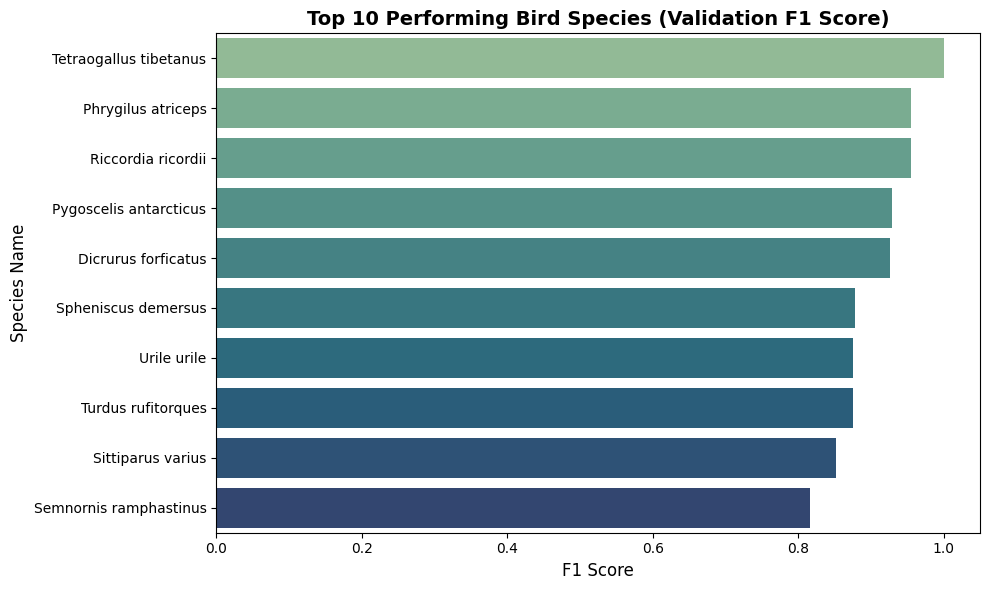

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_species = results_df.sort_values("f1_score", ascending=False).head(10)
print("\nTop 10 Performing Bird Species:")
print(top10_species[["species_name", "f1_score", "auc"]])

plt.figure(figsize=(10, 6))
barplot = sns.barplot(y="species_name", x="f1_score", data=top10_species, palette="crest")
plt.title("Top 10 Performing Bird Species (Validation F1 Score)", fontsize=14, weight="bold")
plt.xlabel("F1 Score", fontsize=12)
plt.ylabel("Species Name", fontsize=12)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

Random location based prediction (need to see how to cross verify)


 Top 5 Predicted Bird Species for Oxford, UK:
            species_name  probability
33      Phaetusa simplex     0.180735
34         Fregata minor     0.148895
22        Columbina inca     0.129619
217  Regulus ignicapilla     0.114768
128        Turdus merula     0.114716


/var/folders/h0/0kms8dqj2q3_fm6zm8kf0kdw0000gq/T/ipykernel_67950/2808713725.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


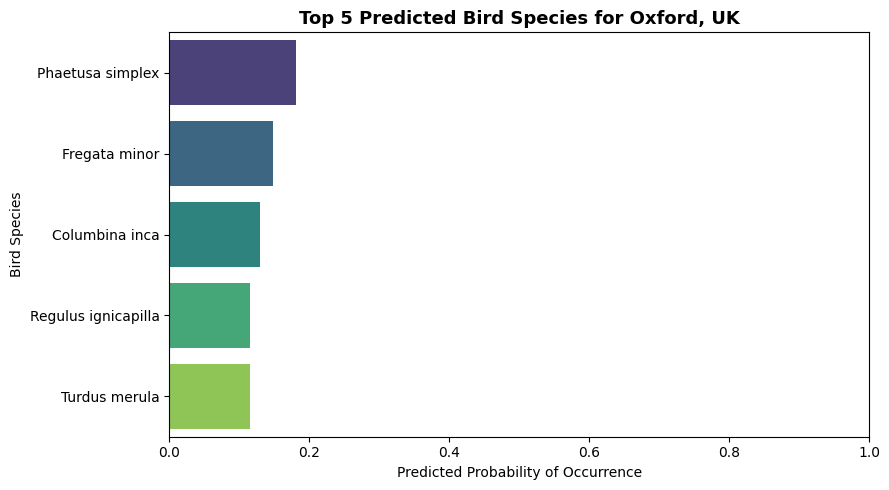

In [70]:
new_location = pd.DataFrame([{
    "latitude": 51.75,        # Oxford latitude
    "longitude": -1.25,       # Oxford longitude
    "Tmin_avg": 4.5,          # °C, average winter minimum
    "Tmax_avg": 14.5,         # °C, average summer maximum
    "Prec_avg": 60.0          # mm, average monthly precipitation
}])

new_location = new_location[["latitude", "longitude", "Tmin_avg", "Tmax_avg", "Prec_avg"]]

# Predict probability for each species using trained Random Forest models
species_probs = {}
for sid, model in zip(results_df["species_id"], results_df["model"]):
    try:
        prob = model.predict_proba(new_location)[0, 1]
        species_probs[sid] = prob
    except Exception as e:
        continue  # just in case any model fails, skip

# probability merge with species name
species_probs_df = pd.DataFrame({
    "species_id": list(species_probs.keys()),
    "probability": list(species_probs.values())
})

species_probs_df = species_probs_df.merge(
    results_df[["species_id", "species_name"]],
    on="species_id",
    how="left"
)

#Sort and display top 5 predicted bird species
top5_predictions = species_probs_df.sort_values("probability", ascending=False).head(5)
print("\n Top 5 Predicted Bird Species for Oxford, UK:")
print(top5_predictions[["species_name", "probability"]])

#Plot results for visual clarity
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))
sns.barplot(
    y="species_name",
    x="probability",
    data=top5_predictions,
    palette="viridis"
)
plt.title("Top 5 Predicted Bird Species for Oxford, UK", fontsize=13, weight="bold")
plt.xlabel("Predicted Probability of Occurrence")
plt.ylabel("Bird Species")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Note to Sam, I stopped here

Load and Merge Test Data (birds only)

In [ ]:
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()


(725335, 10)
['latitude', 'longitude', 'taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label', 'Tmin_avg', 'Tmax_avg', 'Prec_avg']


,latitude,longitude,taxon_id,taxon_name,lat_rounded,lon_rounded,label,Tmin_avg,Tmax_avg,Prec_avg
0,19.289352,-89.842890,3117,Patagioenas flavirostris,19.28935,-89.84289,20,18.850333,32.721000,91.750000
1,20.777590,-88.534240,3117,Patagioenas flavirostris,20.77759,-88.53424,20,18.824667,32.724334,103.833333
2,21.513868,-86.804565,3117,Patagioenas flavirostris,21.51387,-86.80457,20,21.658333,30.716667,100.250000
4,21.509193,-88.522995,3117,Patagioenas flavirostris,21.50919,-88.52299,20,19.734470,31.497727,73.250000
5,15.438323,-86.370710,3117,Patagioenas flavirostris,15.43832,-86.37071,20,20.861000,30.976333,95.416667


Test Prediction

In [ ]:
test_features = test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]]

proba_matrix = []
species_ids = []

for _, row in results_df.iterrows():
    sp = row["species_id"]
    model = row["model"]
    probs = model.predict_proba(test_features)[:, 1]
    proba_matrix.append(probs)
    species_ids.append(sp)

proba_df = pd.DataFrame(np.array(proba_matrix).T, columns=species_ids)
print("Predicted probabilities for all species on test data.")

Predicted probabilities for all species on test data.


In [ ]:
# Sanity check for train and test data consistency
import numpy as np

# 1. Check for overlapping coordinates between train and test
shared_coords_test = set(map(tuple, X_train[['latitude', 'longitude']].values)) & set(map(tuple, X_test[['latitude', 'longitude']].values))
print(f"Overlapping coordinates between train & test: {len(shared_coords_test)}")

# 2. Basic test feature check
print("\nTest dataset shape:", X_test.shape)
print("Train dataset shape:", X_train.shape)
print("\nAny missing values in test set:", X_test.isnull().sum().sum())

# 3. Ensure test has the same columns as train
train_cols = set(X_train.columns)
test_cols = set(X_test.columns)
if train_cols == test_cols:
    print("\n Test columns match training columns exactly.")
else:
    print("\n Column mismatch detected!")
    print("Columns only in train:", train_cols - test_cols)
    print("Columns only in test:", test_cols - train_cols)

# 4. Compare feature distribution roughly (first few features)
print("\nFeature distribution comparison (mean ± std for first few columns):")
for col in list(X_train.columns)[:5]:
    print(f"{col:<20} Train: {X_train[col].mean():.4f} ± {X_train[col].std():.4f} | Test: {X_test[col].mean():.4f} ± {X_test[col].std():.4f}")

# 5. Quick model sanity run on a small test subset
try:
    sample_preds = model.predict(X_test.head(5))
    print("\nSample predictions on test subset:", sample_preds)
except Exception as e:
    print("\n Prediction sanity check failed:", e)


Overlapping coordinates between train & test: 0

Test dataset shape: (725335, 5)
Train dataset shape: (120155, 5)

Any missing values in test set: 0

 Test columns match training columns exactly.

Feature distribution comparison (mean ± std for first few columns):
latitude             Train: 15.5491 ± 32.0203 | Test: 12.8262 ± 29.2414
longitude            Train: -9.3366 ± 95.9662 | Test: 19.4226 ± 76.1083
Tmin_avg             Train: -0.0008 ± 1.0007 | Test: 11.1498 ± 10.0132
Tmax_avg             Train: -0.0008 ± 1.0002 | Test: 23.0859 ± 10.3923
Prec_avg             Train: -0.0007 ± 0.9982 | Test: 78.5765 ± 60.0666

Sample predictions on test subset: [0 0 0 0 0]


top predicted species for a random test location

In [ ]:
sample_idx = np.random.randint(0, len(test_df))
sample_location = test_df.iloc[sample_idx]
lat, lon = sample_location["latitude"], sample_location["longitude"]

species_probs = proba_df.iloc[sample_idx].values
top10_idx = np.argsort(species_probs)[::-1][:10]
top10_species = proba_df.columns[top10_idx]
top10_probs = species_probs[top10_idx]

true_species = sample_location["taxon_id"]

print(f"\nTest location #{sample_idx} (Lat: {lat}, Lon: {lon})")
print("Top 10 predicted bird species:")
for rank, (sp, prob) in enumerate(zip(top10_species, top10_probs), 1):
    check = "✅" if sp == true_species else ""
    print(f"{rank}. Species {sp} — Probability {prob:.4f} {check}")

print(f"\nTrue observed species: {true_species}")


Test location #592888 (Lat: 20.69828, Lon: 95.130936)
Top 10 predicted bird species:
1. Species 100 — Probability 0.2117 
2. Species 34 — Probability 0.1819 
3. Species 80 — Probability 0.1308 
4. Species 33 — Probability 0.1151 
5. Species 154 — Probability 0.0965 
6. Species 257 — Probability 0.0816 
7. Species 248 — Probability 0.0665 
8. Species 16 — Probability 0.0641 
9. Species 244 — Probability 0.0491 
10. Species 277 — Probability 0.0332 

True observed species: 12910


plot


Average F1 across species: 0.314
Average AUC across species: 0.962


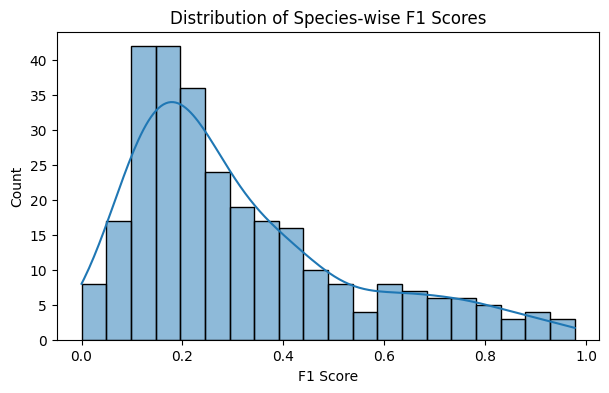

In [ ]:
mean_f1 = results_df["f1_score"].mean()
mean_auc = results_df["auc"].mean()
print(f"\nAverage F1 across species: {mean_f1:.3f}")
print(f"Average AUC across species: {mean_auc:.3f}")

plt.figure(figsize=(7,4))
sns.histplot(results_df["f1_score"], bins=20, kde=True)
plt.title("Distribution of Species-wise F1 Scores")
plt.xlabel("F1 Score")
plt.show()